In questo esercizio si analizza il catalogo VIPERS in formato FITS usando la classe FitsManager. Si selezionano galassie con redshift valido, si calcolano le distanze comoventi in tre modelli cosmologici diversi e si confrontano le distribuzioni spaziali delle galassie.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt    
import sys
from astropy.io import fits
from astropy.cosmology import LambdaCDM
from astropy import units as u

sys.path.append('../../')
from pyACC.fits_wrapper import FitsManager

In [58]:
vipers_sample = FitsManager("VIPERS_W1.fits.gz")

2025-06-19 17:57:54.507566 :: FitsManager :: INFO :: Fits open succesfully


In [59]:
vipers_sample.get_header(1)

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                   91 / width of table in bytes                        
NAXIS2  =                60528 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   16 / number of fields in each row                   
TTYPE1  = 'id_IAU  '           / label for field   1                            
TFORM1  = '16A     '           / data format of field: ASCII Character          
TTYPE2  = 'num     '           / label for field   2                            
TFORM2  = '9A      '           / data format of field: ASCII Character          
TTYPE3  = 'alpha   '        

In [60]:
data = vipers_sample.get_data(1)
print(data.columns.names)

['id_IAU', 'num', 'alpha', 'delta', 'selmag', 'errselmag', 'pointing', 'quadrant', 'zspec', 'zflg', 'norm', 'epoch', 'photoMask', 'tsr', 'ssr', 'classFlag']


In [61]:
RA, DEC, redshift = data["alpha"], data["delta"], data["zspec"] # Estrae coordinate celesti (RA, DEC) e redshift
zflg = data["zflg"] # Estrae flag di qualità del redshift, ovvero quanto è affidabile il redshift misurato

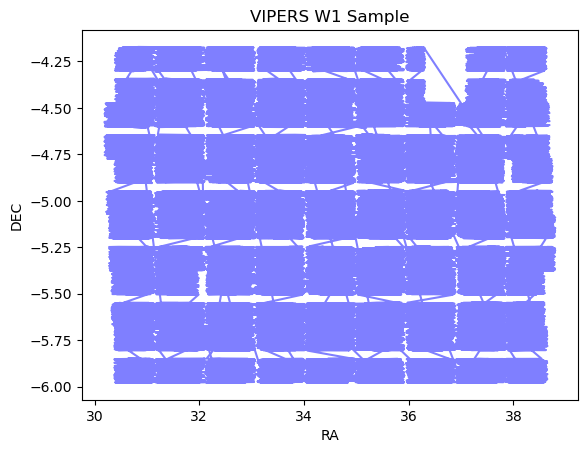

In [62]:
plt.plot(RA, DEC, 'blue', alpha=0.5) # Crea uno scatter plot delle posizioni celesti
plt.title("VIPERS W1 Sample")
plt.xlabel("RA")
plt.ylabel("DEC")
plt.show()

In [63]:
# Seleziono solo galassie con un certo redshift
cut_zspec = np.where((redshift>0.3) & (redshift<1.5) & (zflg>=2) & (zflg<=9))[0]
len(cut_zspec), len(redshift)

(48428, 60528)

NB: in questo filtro si selezionano solo le galassie con redshift tra 0.3 e 1.5: quelle troppo vicine sono meno utili per gli studi cosmologici, mentre quelle troppo lontane tendono ad avere misure meno precise. Inoltre, si tengono solo i redshift con un flag di qualità tra 2 e 9. Questo flag indica quanto è affidabile la misura del redshift: valori più alti significano maggiore sicurezza. Per esempio, un flag 4 indica un redshift molto sicuro, mentre un flag 2 è accettabile ma con qualche incertezza. Anche il flag 9 è incluso: si tratta di misure basate su una sola riga spettrale, quindi più deboli, ma comunque considerate valide se ben identificate.

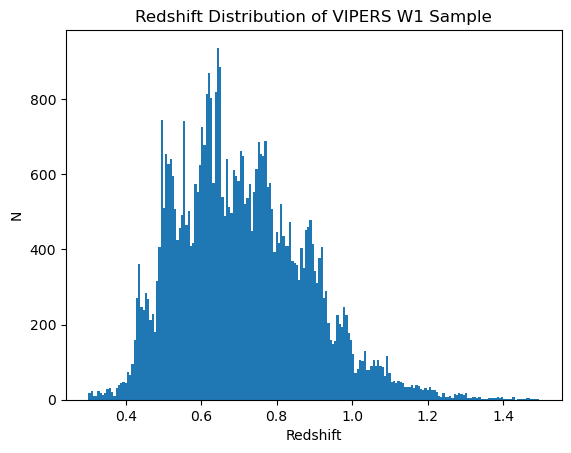

In [64]:
plt.hist(redshift[cut_zspec], bins=200) # Istogramma della distribuzione in redshift delle galassie selezionate
plt.title("Redshift Distribution of VIPERS W1 Sample")
plt.xlabel("Redshift")
plt.ylabel("N")
plt.show()

In [65]:
# Converto il redshift in distanza comovente in tre cosmologie diverse

fiducial_cosmology = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7) # primo modello
dc1=fiducial_cosmology.comoving_distance(redshift[cut_zspec]) #calcolo distanza comovente

X1 = dc1 * np.cos(np.radians(DEC[cut_zspec])) * np.cos(np.radians(RA[cut_zspec])) # Converto le coordinate celesti in coordinate cartesiane comoventi
Y1 = dc1 * np.cos(np.radians(DEC[cut_zspec])) * np.sin(np.radians(RA[cut_zspec]))
Z1 = dc1 * np.sin(np.radians(DEC[cut_zspec]))

fiducial_cosmology = LambdaCDM(H0=70, Om0=0.1, Ode0=0.9) # secondo modello
dc2=fiducial_cosmology.comoving_distance(redshift[cut_zspec])

X2 = dc2 * np.cos(np.radians(DEC[cut_zspec])) * np.cos(np.radians(RA[cut_zspec]))
Y2 = dc2 * np.cos(np.radians(DEC[cut_zspec])) * np.sin(np.radians(RA[cut_zspec]))
Z2 = dc2 * np.sin(np.radians(DEC[cut_zspec]))

fiducial_cosmology = LambdaCDM(H0=70, Om0=0.5, Ode0=0.5) # terzo modello
dc3=fiducial_cosmology.comoving_distance(redshift[cut_zspec])

X3 = dc3 * np.cos(np.radians(DEC[cut_zspec])) * np.cos(np.radians(RA[cut_zspec]))
Y3 = dc3 * np.cos(np.radians(DEC[cut_zspec])) * np.sin(np.radians(RA[cut_zspec]))
Z3 = dc3 * np.sin(np.radians(DEC[cut_zspec]))

<>:30: SyntaxWarning: invalid escape sequence '\O'
<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:30: SyntaxWarning: invalid escape sequence '\O'
<>:31: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_74582/2536528740.py:30: SyntaxWarning: invalid escape sequence '\O'
  ax[1,1].hist(dc2, bins=100, color="r", alpha=0.5, label="$\Omega_M=0.1$")
/tmp/ipykernel_74582/2536528740.py:31: SyntaxWarning: invalid escape sequence '\O'
  ax[1,1].hist(dc3, bins=100, color="b", alpha=0.5, label="$\Omega_M=0.5$")


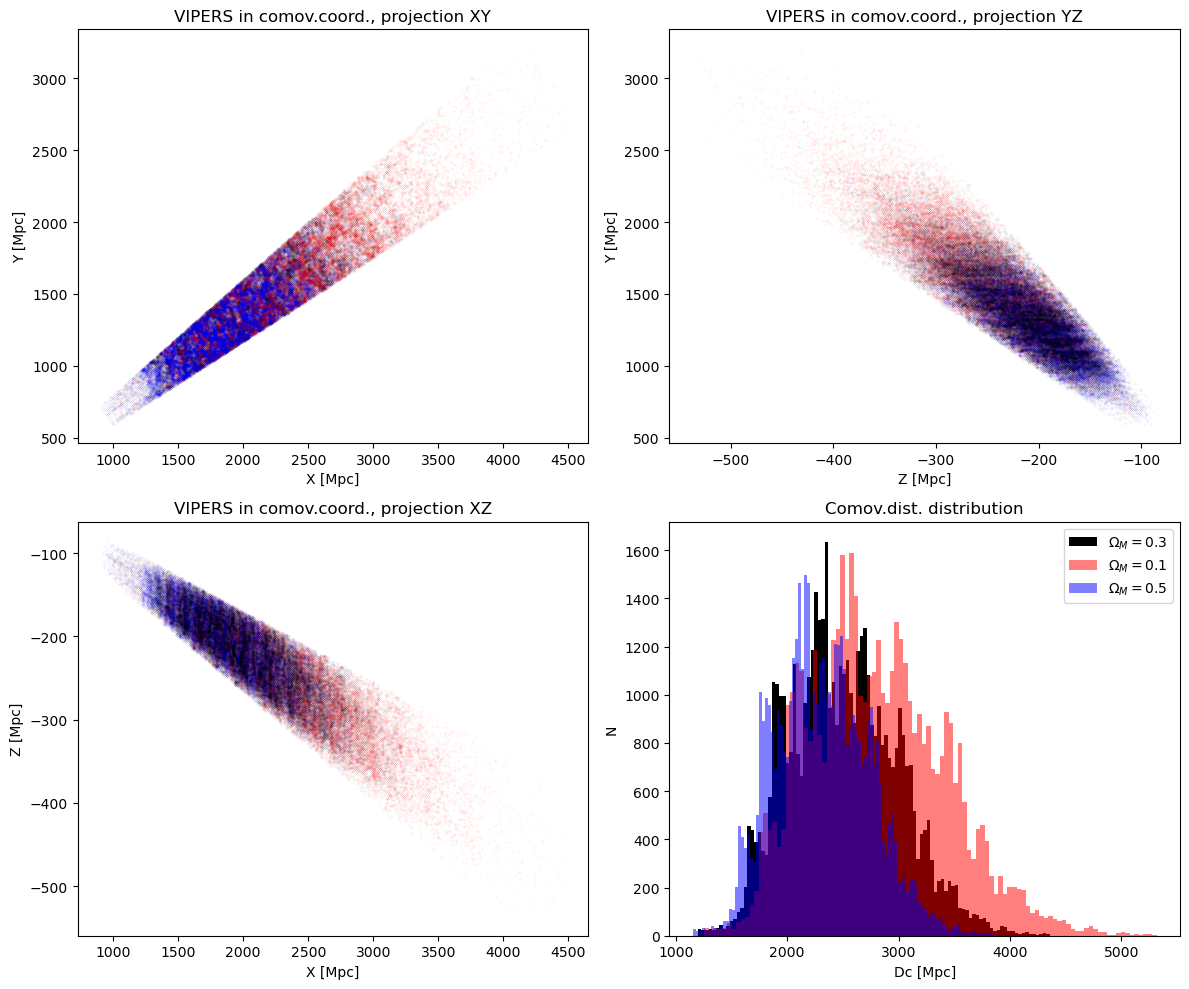

In [66]:
figure, ax = plt.subplots(2, 2) # Crea una figura con 2 righe e 2 colonne di sottotrame
figure.set_size_inches(12, 10)

# Primo subplot: proiezione XY delle tre cosmologie
ax[0,0].plot(X1, Y1, ".", ms=0.05, color="k")
ax[0,0].plot(X2, Y2, ".", ms=0.05, color="r")
ax[0,0].plot(X3, Y3, ".", ms=0.05, color="b")
ax[0,0].set_title("VIPERS in comov.coord., projection XY") 
ax[0,0].set_xlabel("X [Mpc]")
ax[0,0].set_ylabel("Y [Mpc]")

# Secondo subplot: proiezione YZ delle tre cosmologie
ax[0,1].plot(Z2, Y2, ".", ms=0.05, color="r")
ax[0,1].plot(Z3, Y3, ".", ms=0.05, color="b")
ax[0,1].plot(Z1, Y1, ".", ms=0.05, color="k")
ax[0,1].set_title("VIPERS in comov.coord., projection YZ") 
ax[0,1].set_xlabel("Z [Mpc]")
ax[0,1].set_ylabel("Y [Mpc]")

# Terzo subplot: proiezione XZ delle tre cosmologie
ax[1,0].plot(X2, Z2, ".", ms=0.05, color="r")
ax[1,0].plot(X3, Z3, ".", ms=0.05, color="b")
ax[1,0].plot(X1, Z1, ".", ms=0.05, color="k")
ax[1,0].set_title("VIPERS in comov.coord., projection XZ") 
ax[1,0].set_xlabel("X [Mpc]")
ax[1,0].set_ylabel("Z [Mpc]")

# Quarto subplot: istogramma delle distanze comoventi per ciascun modello cosmologico
ax[1,1].hist(dc1, bins=100, color="k", label=r"$\Omega_M=0.3$")
ax[1,1].hist(dc2, bins=100, color="r", alpha=0.5, label="$\Omega_M=0.1$")
ax[1,1].hist(dc3, bins=100, color="b", alpha=0.5, label="$\Omega_M=0.5$")
ax[1,1].set_title("Comov.dist. distribution")
ax[1,1].set_xlabel("Dc [Mpc]")
ax[1,1].set_ylabel("N")
ax[1,1].legend()

figure.tight_layout()
